In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

# Display all columns and rows for better visibility
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)

# Load cleaned and merged dataset
df = pd.read_csv("data/final.csv")

## Dropped Columns and Indices Based on Analytical Insights

In [6]:
# Standardize column order (year and country code first)
df = df[["year", "iso_code"] + [col for col in df.columns if col not in ["year", "iso_code"]]]

# Rename confusing column names for clarity
df.rename(columns={
    "country_x": "country",
    "co2_per_capita_y": "co2_per_capita",
    "cumulative_co2_y": "cumulative_co2"
}, inplace=True)

# Exclude small countries with excessive missing data
df = df[~df["country"].isin(["Andorra", "Liechtenstein", "Monaco", "Saint Kitts and Nevis", "San Marino"])]

# Drop columns with weak correlation and low predictive contribution
df.drop(["energy_per_capita", "other_renewables_share_elec", "infrastructure", "capacity"], axis=1, inplace=True)

# Remove 2023 data due to observed inconsistencies and corrupted records
df = df[df["year"] != 2023]

## Handling Missing Values

In [8]:
df.isnull().sum()

year                  0
iso_code              0
gain                  0
readiness             0
vulnerability         0
economic            140
governance           84
health               28
exposure              0
ecosystems          196
habitat               0
sensitivity         168
country               0
co2_per_capita        0
cumulative_co2        0
share_global_co2      0
person_gdp          728
population            0
dtype: int64

## Filling Missing "person_gdp" Values Using XGBoost

Fitting 3 folds for each of 32 candidates, totalling 96 fits
MAE:  834.88
RMSE: 1384.20
R²:   0.9933


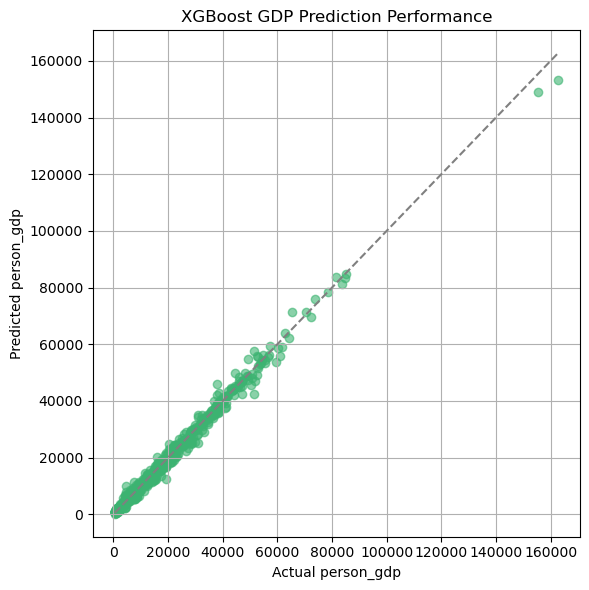

In [10]:
# Filter out rows where person_gdp is not missing
df_notna = df[df["person_gdp"].notna()]

# Define input and target variables
X = df_notna.drop(columns=["person_gdp", "country", "iso_code"])
y = df_notna["person_gdp"]

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Set up XGBoost model and hyperparameter grid
model = XGBRegressor(objective="reg:squarederror", random_state=2)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Perform grid search with cross-validation
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

# Retrieve best model and generate predictions
best_model = grid.best_estimator_
y_pred = best_model.predict(X_val)

# Evaluate model performance
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

# Plot actual vs predicted values
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.6, color="mediumseagreen")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "--", color="gray")
plt.xlabel("Actual person_gdp")
plt.ylabel("Predicted person_gdp")
plt.title("XGBoost GDP Prediction Performance")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
#### Assigning "person_gdp" Predictions
# 1. Select rows where person_gdp is missing
df_missing = df[df["person_gdp"].isna()].copy()

# 2. Select the same features used in the model
X_missing = df_missing.drop(columns=["person_gdp", "country", "iso_code"])

# 3. Generate predictions for missing rows
predicted_values = best_model.predict(X_missing)

# 4. Write predicted person_gdp values back into the main dataframe
df.loc[df["person_gdp"].isna(), "person_gdp"] = predicted_values

## Imputing Missing Readiness Components via Modeling

In [13]:
## Modeling Missing Readiness Components Using XGBoost

# Generic model function: trains on available data and imputes missing targets

def evaluate_regression_model(df, target, features, model_label="Model"):
    df_train = df[df[target].notnull() & df[features].notnull().all(axis=1)]
    X_train, y_train = df_train[features], df_train[target]
    df_missing = df[df[target].isnull() & df[features].notnull().all(axis=1)]

    model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
    model.fit(X_train, y_train)

    # Evaluation metrics
    y_pred = model.predict(X_train)
    r2 = r2_score(y_train, y_pred)
    mae = mean_absolute_error(y_train, y_pred)

    print(f"\nTarget: {target}")
    print(f"Features: {features}")
    print(f"R² Score: {r2:.3f}")
    print(f"Mean Absolute Error: {mae:.4f}")

    # Feature importance report
    importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
    print(f"\n{model_label} - Feature Importances:")
    print(importance)

    # Imputation of missing target values
    if not df_missing.empty:
        df.loc[df_missing.index, target] = model.predict(df_missing[features])
        print(f"Imputed rows for '{target}': {len(df_missing)}")
    else:
        print(f"No missing rows to predict for '{target}'.")

# Model runs for various target variables
evaluate_regression_model(
    df,
    target="health",
    features=["vulnerability", "sensitivity", "exposure", "habitat", "ecosystems"],
    model_label="Health Model"
)

evaluate_regression_model(
    df,
    target="governance",
    features=["vulnerability", "sensitivity", "exposure", "habitat", "ecosystems"],
    model_label="Governance Model"
)

evaluate_regression_model(
    df,
    target="economic",
    features=["readiness", "gain", "person_gdp"],
    model_label="Economic Model"
)

evaluate_regression_model(
    df,
    target="sensitivity",
    features=["economic", "readiness", "gain", "person_gdp", "health"],
    model_label="Sensitivity Model"
)

evaluate_regression_model(
    df,
    target="ecosystems",
    features=["vulnerability", "sensitivity", "exposure", "habitat", "health"],
    model_label="Ecosystems Model"
)


Target: health
Features: ['vulnerability', 'sensitivity', 'exposure', 'habitat', 'ecosystems']
R² Score: 0.980
Mean Absolute Error: 0.0179

Health Model - Feature Importances:
vulnerability    0.855297
exposure         0.048395
habitat          0.034321
sensitivity      0.031603
ecosystems       0.030384
dtype: float32
Imputed rows for 'health': 28

Target: governance
Features: ['vulnerability', 'sensitivity', 'exposure', 'habitat', 'ecosystems']
R² Score: 0.937
Mean Absolute Error: 0.0436

Governance Model - Feature Importances:
vulnerability    0.459698
ecosystems       0.159186
habitat          0.153997
exposure         0.134845
sensitivity      0.092274
dtype: float32
Imputed rows for 'governance': 84

Target: economic
Features: ['readiness', 'gain', 'person_gdp']
R² Score: 0.805
Mean Absolute Error: 0.0436

Economic Model - Feature Importances:
readiness     0.840715
person_gdp    0.098993
gain          0.060292
dtype: float32
Imputed rows for 'economic': 140

Target: sensitivity

## Log Transformation

In [15]:
columns_to_log = ["cumulative_co2", "person_gdp", "population"]

# To safely handle zeros or negative values, log1p is applied: log(1 + x)
for col in columns_to_log:
    df[f"{col}_log"] = np.log1p(df[col])  # Natural log of (1 + value)

In [16]:
df.head()

,year,iso_code,gain,readiness,vulnerability,economic,governance,health,exposure,ecosystems,habitat,sensitivity,country,co2_per_capita,cumulative_co2,share_global_co2,person_gdp,population,cumulative_co2_log,person_gdp_log,population_log
0,1995,AFG,34.783530,0.308182,0.612511,0.496497,0.128090,0.748302,0.480512,0.515884,0.602933,0.419587,Afghanistan,0.083,66.358,0.006,721.179181,17065836.0,4.210022,6.582273,16.652589
1,1996,AFG,34.775074,0.308181,0.612679,0.496497,0.128090,0.748302,0.480512,0.516995,0.604235,0.419307,Afghanistan,0.077,67.728,0.006,679.499268,17763265.0,4.230157,6.522827,16.692643
2,1997,AFG,34.988812,0.312614,0.612837,0.496497,0.141392,0.748302,0.480512,0.518030,0.605583,0.419055,Afghanistan,0.071,69.032,0.005,642.244136,18452100.0,4.248952,6.466524,16.730689
3,1998,AFG,35.293407,0.317047,0.611179,0.496497,0.154694,0.748302,0.480512,0.518156,0.606909,0.418794,Afghanistan,0.067,70.311,0.005,610.238711,19159996.0,4.267051,6.415488,16.768335
4,1999,AFG,35.177507,0.313378,0.609828,0.496497,0.143689,0.748302,0.480512,0.518156,0.608137,0.419433,Afghanistan,0.055,71.402,0.004,579.114900,19887791.0,4.282234,6.363226,16.805617


## Linear Regression Model for Readiness Prediction

5-Fold CV Average RMSE: 0.06326100894268491
5-Fold CV Average R²: 0.8067963368294105


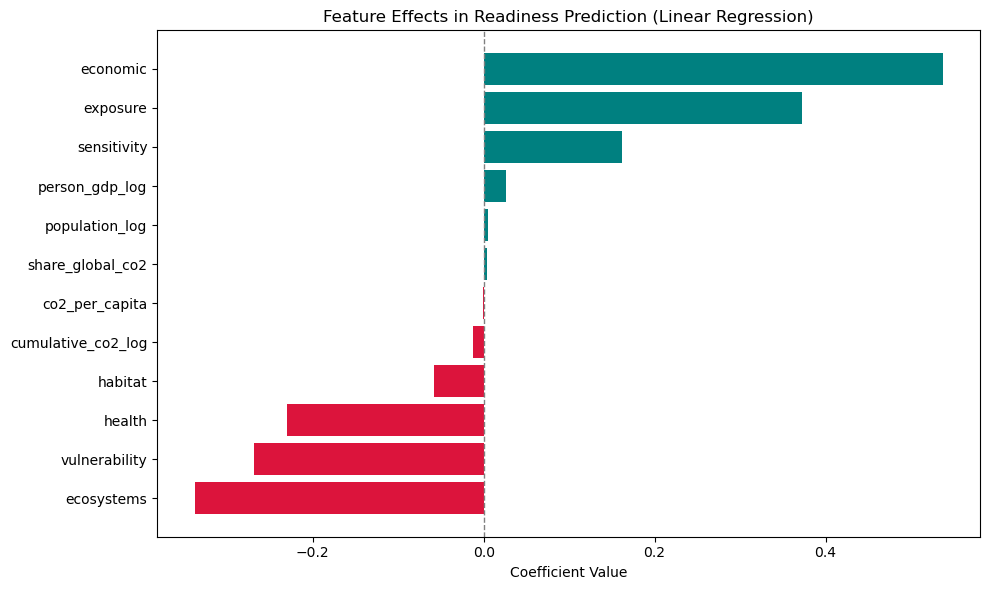

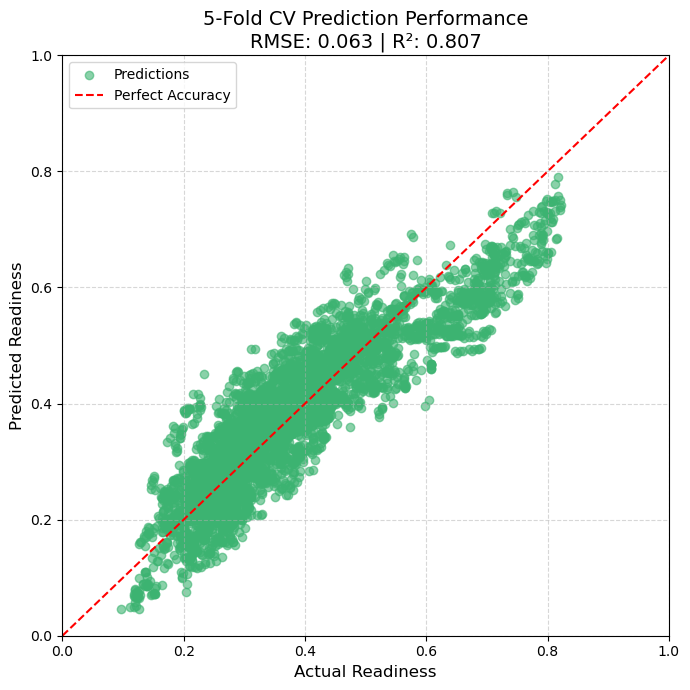

In [18]:
# Feature selection, excluding original (pre-log) variables
features = [col for col in df.columns if col not in [
    "gain", "readiness", "country", "iso_code", "year", "governance",
    "cumulative_co2", "person_gdp", "population"
]]

X = df[features].values
y = df["readiness"].values

# Apply 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_list = []
r2_list = []
y_tests = []
y_preds = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    rmse_list.append(rmse)
    r2_list.append(r2)
    y_tests.extend(y_test)
    y_preds.extend(y_pred)

# Print average model performance
print("5-Fold CV Average RMSE:", np.mean(rmse_list))
print("5-Fold CV Average R²:", np.mean(r2_list))

# Train final model on all data
final_model = LinearRegression()
final_model.fit(X, y)

# Visualize feature coefficients
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": final_model.coef_
}).sort_values(by="Coefficient", ascending=True)

plt.figure(figsize=(10, 6))
colors = ["crimson" if coef < 0 else "teal" for coef in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(x=0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Coefficient Value")
plt.title("Feature Effects in Readiness Prediction (Linear Regression)")
plt.tight_layout()
plt.show()

# Visualize prediction performance
plt.figure(figsize=(7, 7))
plt.scatter(y_tests, y_preds, alpha=0.6, color='mediumseagreen', label='Predictions')
plt.plot([0, 1], [0, 1], 'r--', label='Perfect Accuracy')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('Actual Readiness', fontsize=12)
plt.ylabel('Predicted Readiness', fontsize=12)
plt.title(f'5-Fold CV Prediction Performance\nRMSE: {np.mean(rmse_list):.3f} | R²: {np.mean(r2_list):.3f}', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## XGBoost Model for Readiness Prediction

Cross-Validated R² Scores: [0.90232124 0.86443102 0.83115368 0.8574423  0.82166305]
Mean R² Score (CV): 0.8554
RMSE: 0.0150
R² Score (Test Set): 0.9892


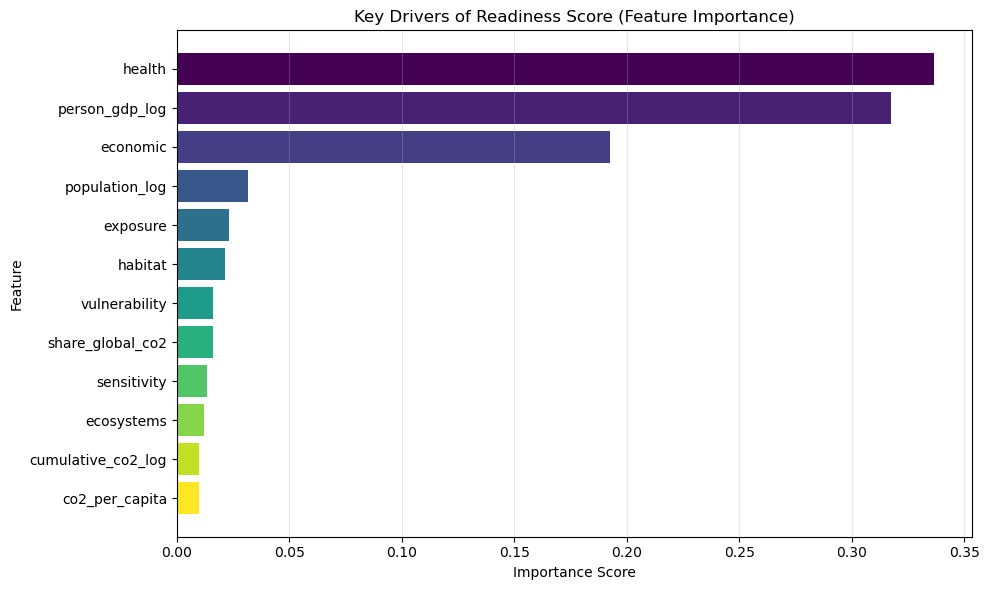

In [20]:
# Define features and target variable
drop_cols = ["readiness", "iso_code", "country", "year", "gain", "governance", "cumulative_co2", "person_gdp", "population"]
X = df.drop(columns=drop_cols)
y = df["readiness"]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize XGBoost regressor with custom hyperparameters
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Perform 5-Fold Cross-Validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"Cross-Validated R² Scores: {cv_scores}")
print(f"Mean R² Score (CV): {cv_scores.mean():.4f}")

# Train the model on the training set
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {mse ** 0.5:.4f}")
print(f"R² Score (Test Set): {r2:.4f}")

# Feature importance analysis
importances = model.feature_importances_
features = X.columns

df_importances = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(df_importances)))
plt.barh(df_importances["feature"], df_importances["importance"], color=colors)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Key Drivers of Readiness Score (Feature Importance)")
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Visualizing XGBoost Prediction Accuracy for Readiness

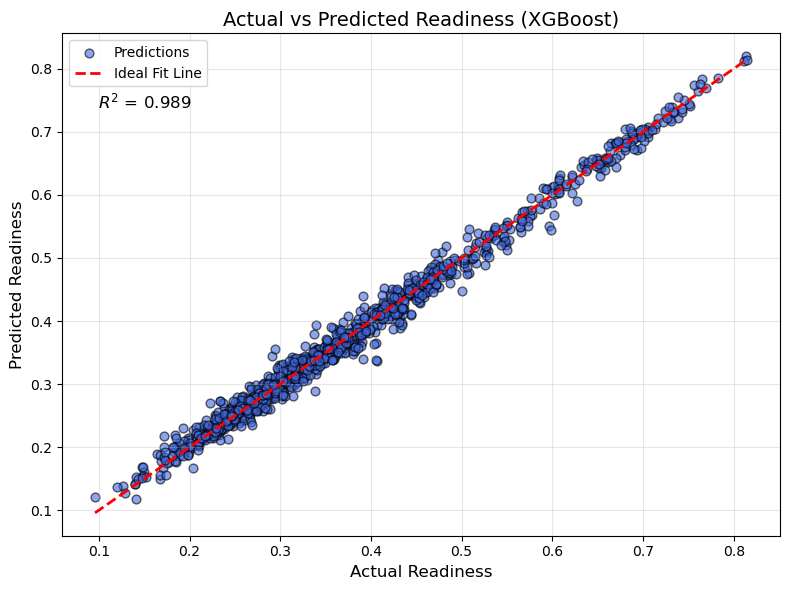

In [22]:
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolors='k', s=40, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Ideal Fit Line')

plt.title("Actual vs Predicted Readiness (XGBoost)", fontsize=14)
plt.xlabel("Actual Readiness", fontsize=12)
plt.ylabel("Predicted Readiness", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.text(0.05, 0.85, f"$R^2$ = {r2:.3f}", fontsize=12, transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

In [23]:
# Compare First 10 Actual vs Predicted Readiness Scores
df_compare = pd.DataFrame({
    "Actual Readiness": y_test[:10].values,
    "Predicted Readiness": y_pred[:10]
})

# Display values rounded to 4 decimal places
print(df_compare.round(4))

   Actual Readiness  Predicted Readiness
0            0.4131               0.4137
1            0.5625               0.5636
2            0.3811               0.3581
3            0.4150               0.4169
4            0.6314               0.6445
5            0.3614               0.3525
6            0.4319               0.4051
7            0.4414               0.4508
8            0.6013               0.5686
9            0.1854               0.1763


## Conclusion: The Ready, the Responsible, and the Left Behind

### Throughout this study, I kept asking: Who is prepared for the climate crisis—and who contributed most to creating it?  
### My final visualization brings this striking contrast into focus.

![Climate Justice Triangle](image.png)

🌍 Triple Categorization – The Balance of Readiness and Responsibility
In this analysis, countries were grouped based on their climate readiness levels and per capita CO₂ emissions:

🔥 Very High Readiness + Highest Emissions → United States, Saudi Arabia, Australia ➤ These nations have contributed most to the climate crisis while securing the strongest protections for themselves.

🌱 Very High Readiness + Lowest Emissions → Tuvalu, Sweden, Barbados ➤ Inspiring examples of countries living with low emissions and taking proactive, effective measures.

🌪️ Very Low Readiness + Lowest Emissions → Burundi, Uganda, Malawi ➤ Countries that did not cause the crisis but remain among the most vulnerable to its consequences.

🔍 Final Reflection – If the Solution Is Collective, So Is the Hope
This project was more than a data analysis; it was a call to make climate injustice visible. The evidence is clear: responsibility is not equally shared, and vulnerability is anything but random.

Yet inspiring nations show us a way forward:

🌿 Tuvalu: Nature-based solutions and local community involvement ☀️ Barbados: Renewable energy and coastal protection strategies 🌍 Sweden: Ethics-driven sustainable development

What makes these examples powerful:

Community-centered preparedness

Low-carbon living strategies

Effective and inclusive policy frameworks

🛠️ Recommended Practices – For Global Adaptation
Nature-based solution approaches

Strategies for transitioning to renewable energy

Adaptation models centered around local participation

International cooperation that supports equitable resource distribution

Transparent data sharing and accountability mechanisms

In conclusion: This is not just a warning—it’s also a roadmap. If the solution is collective, then hope is real. 🌱